# Module Goal
This notebook's primary objective is to perform unsupervised learning (clustering) on the dataset's features to identify inherent groups or segments within the data. This segmentation is crucial for targeted analysis, business strategy, and personalization.

# Setup and Libraries

### Library Imports and Environment Initialization

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import regex as re
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
from sklearn.preprocessing import RobustScaler

%matplotlib inline
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [5]:
import warnings
warnings.filterwarnings('ignore')

### Data Loading and Preprocessing

In [6]:
df = pd.read_csv(DATA_RAW / "divar_real_estate_ads.csv")


In [7]:
df_house = pd.read_csv(DATA_PROCESSED / "df_house_sell.csv")
df_apartment = pd.read_csv(DATA_PROCESSED / "df_apartment_sell.csv")

### Feature Selection for Clustering


In [8]:
df_house

,cat2_slug,cat3_slug,title,description,user_type,city_slug,neighborhood_slug,age,building_size,land_size,...,rooms_count,has_parking,has_balcony,has_elevator,has_warehouse,has_heating_system,has_cooling_system,has_warm_water_provider,location_latitude,location_longitude
0,residential-sell,house-villa-sell,ویلا نما مدرن‌ ویو جنگل کل ۳ میلیارد,❌❌ قوی ترین فایلینگ منطقه❌❌ زمین :150 بنا:90 ۲...,مشاور املاک,nur,NaN,1.0,170.0,100.0,...,2,1,1,0,1,shoofaj,air_conditioner,package,36.575436,52.026459
1,residential-sell,house-villa-sell,ویلایی ۱۰۳مترسندار,خانه ویلایی ۱۰۳مترسندارباحیاط وزیرزمین واقع در...,NaN,karaj,other,24.0,65.0,103.0,...,1,1,1,0,1,heater,water_cooler,water_heater,35.841949,50.955498
2,residential-sell,house-villa-sell,خانه ویلایی در چایکنار به طرف ابرسان,دارای زیر زمین مجزا مناسب کارگاه و انباری \nما...,NaN,tabriz,NaN,29.0,100.0,140.0,...,1,0,1,0,1,heater,air_conditioner,water_heater,38.074223,46.317448
3,residential-sell,house-villa-sell,ویلایی2طبقه طبرسی38 فروش یامعاوضه بااطراف حرم,باعرض سلام و تسلیت ایام\nیک باب منزل ویلایی2طب...,NaN,mashhad,north-tabars,17.0,160.0,125.0,...,2,1,1,0,1,heater,water_cooler,water_heater,36.327621,59.671322
4,residential-sell,house-villa-sell,فروش ویلاکلنگی ۵۰۷متری باسند ثبتی در املاک نو...,*********** صداقت در اولویت ، املاک نورسته ...,مشاور املاک,talesh,NaN,24.0,120.0,507.0,...,2,1,1,0,1,heater,split,water_heater,37.794140,48.901390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26283,residential-sell,house-villa-sell,شاندیز 900 متر ویلا مراکشی در حال ساخت/مدرس یک,شاندیز مدرس یک \n\nسبک مراکشی \n\nقابل تهاتر \...,شخصی,shandiz-city,NaN,1.0,300.0,900.0,...,3,1,0,0,1,floor_heating,air_conditioner,package,36.359100,59.427822
26284,residential-sell,house-villa-sell,دوبلکس ویو جنگل،سندتکبرگ،نزدیک جاده،مناسب زندگی,#کد144\n\n❌ویلا دوبلکس نما مدرن \n\nمتراژ زمین...,مشاور املاک,other,NaN,3.0,150.0,220.0,...,3,1,0,0,1,shoofaj,split,water_heater,36.639656,52.470558
26285,residential-sell,house-villa-sell,ویلاباغ ب ق*یمت.شهرکی*مهندسی ساز *آنتیک,↩ یالطیف \n\n♡خـاک ارزشمنــدست و مانــدگار♡ \n...,مشاور املاک,amol,NaN,1.0,130.0,350.0,...,2,1,0,0,1,floor_heating,split,package,36.494888,52.365353
26286,residential-sell,house-villa-sell,ویلایی ۱۷۰ متری,یک باب ویلا .باز سازی شده \n۹۷ متر بنا \n۱۷۰ م...,مشاور املاک,kouchesfahan,NaN,24.0,97.0,170.0,...,2,1,0,0,1,heater,air_conditioner,water_heater,37.321190,49.761536


In [9]:
df_apartment.columns

Index(['cat2_slug', 'cat3_slug', 'title', 'description', 'user_type',
       'city_slug', 'neighborhood_slug', 'building_size', 'age', 'price_value',
       'has_parking', 'has_balcony', 'has_elevator', 'has_warehouse', 'floor',
       'rooms_count', 'total_floors_count', 'has_heating_system',
       'has_cooling_system', 'has_warm_water_provider', 'location_latitude',
       'location_longitude'],
      dtype='object')

In [10]:
df.columns

Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_value', 'rent_to_single', 'rent_type', 'price_mode',
       'price_value', 'credit_mode', 'credit_value', 'rent_credit_transform',
       'transformable_price', 'transformable_credit', 'transformed_credit',
       'transformable_rent', 'transformed_rent', 'land_size', 'building_size',
       'deed_type', 'has_business_deed', 'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',
       'regular_person_capacity', 'extra_person

In [11]:
df_house['property_type'] = 'house'
df_apartment['property_type'] = 'apartment'
df_sell = pd.concat([df_house, df_apartment], ignore_index=True)


In [12]:
df_sell.columns

Index(['cat2_slug', 'cat3_slug', 'title', 'description', 'user_type',
       'city_slug', 'neighborhood_slug', 'age', 'building_size', 'land_size',
       'price_value', 'rooms_count', 'has_parking', 'has_balcony',
       'has_elevator', 'has_warehouse', 'has_heating_system',
       'has_cooling_system', 'has_warm_water_provider', 'location_latitude',
       'location_longitude', 'property_type', 'floor', 'total_floors_count'],
      dtype='object')

In [13]:
df_sell["property_type"].value_counts()

property_type
apartment    43616
house        26288
Name: count, dtype: int64

### Feature Selection for Clustering

In [14]:

features = [
    'age', 'building_size', 'land_size',
   'price_value', 'rooms_count', 'has_parking', 'has_balcony',
    'has_elevator', 'has_warehouse', 'has_heating_system',
    'has_cooling_system', 'has_warm_water_provider', 'location_latitude',
      'location_longitude', 'property_type', 'floor', 'total_floors_count']

my_df = df_sell[features].copy()


In [15]:
my_df

,age,building_size,land_size,price_value,rooms_count,has_parking,has_balcony,has_elevator,has_warehouse,has_heating_system,has_cooling_system,has_warm_water_provider,location_latitude,location_longitude,property_type,floor,total_floors_count
0,1.0,170.0,100.0,1.600000e+08,2,1,1,0,1,shoofaj,air_conditioner,package,36.575436,52.026459,house,NaN,NaN
1,24.0,65.0,103.0,3.850000e+09,1,1,1,0,1,heater,water_cooler,water_heater,35.841949,50.955498,house,NaN,NaN
2,29.0,100.0,140.0,5.200000e+09,1,0,1,0,1,heater,air_conditioner,water_heater,38.074223,46.317448,house,NaN,NaN
3,17.0,160.0,125.0,3.000000e+09,2,1,1,0,1,heater,water_cooler,water_heater,36.327621,59.671322,house,NaN,NaN
4,24.0,120.0,507.0,4.200000e+09,2,1,1,0,1,heater,split,water_heater,37.794140,48.901390,house,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69899,23.0,52.0,NaN,2.000000e+09,1,0,1,0,1,heater,water_cooler,water_heater,35.638554,51.478939,apartment,3.0,4.0
69900,1.0,66.0,NaN,7.900000e+09,1,1,1,1,1,shoofaj,water_cooler,package,35.742710,51.469135,apartment,4.0,5.0
69901,12.0,61.0,NaN,5.950000e+09,1,1,1,1,1,shoofaj,water_cooler,package,35.727104,51.296055,apartment,3.0,5.0
69902,1.0,215.0,NaN,2.800000e+10,3,1,1,1,1,duct_split,duct_split,package,35.760303,51.293949,apartment,2.0,5.0


In [16]:
for col in my_df.columns:
    print(f"🔹 {col} — {my_df[col].nunique()} unique values")
    print(f"🔹 value type : {my_df[col].map(type).value_counts()}")
    print(my_df[col].isna().mean() * 100)
    #print(f"🔹 value type : {df2[col].dtype}")
    #print(df2[col].unique())
    print(my_df[col].value_counts(dropna=False))
    print("-" * 80)


🔹 age — 34 unique values
🔹 value type : age
<class 'float'>    69904
Name: count, dtype: int64
0.0
age
1.0     12238
2.0      5739
14.0     3642
4.0      3419
19.0     3369
9.0      3298
3.0      3008
6.0      2592
7.0      2573
11.0     2487
8.0      2426
24.0     2282
16.0     2192
10.0     2133
5.0      2062
12.0     1925
34.0     1887
21.0     1445
18.0     1438
15.0     1391
17.0     1384
13.0     1247
20.0     1124
22.0      965
29.0      808
33.0      578
23.0      557
26.0      405
25.0      306
27.0      243
32.0      213
31.0      196
28.0      191
30.0      141
Name: count, dtype: int64
--------------------------------------------------------------------------------
🔹 building_size — 608 unique values
🔹 value type : building_size
<class 'float'>    69904
Name: count, dtype: int64
0.0
building_size
100.0     3337
120.0     2377
90.0      2274
80.0      2210
110.0     1991
          ... 
396.0        1
1385.0       1
1260.0       1
490.0        1
752.0        1
Name: count, Le

### Filling the missing data in 'floor' and 'total_floors_count' for house property type

In [17]:
mask = my_df['property_type'] == 'house'

my_df.loc[mask, 'floor'] = 1
my_df.loc[mask, 'total_floors_count'] = 1

### Encoding categorical data types

In [18]:
my_df['has_warm_water_provider'] = my_df['has_warm_water_provider'].fillna(
    my_df['has_warm_water_provider'].mode()[0]
)
my_df = pd.get_dummies(my_df, columns=['has_warm_water_provider'], prefix="warm")

my_df['has_heating_system'] = my_df['has_heating_system'].fillna("missing")
my_df = pd.get_dummies(my_df, columns=['has_heating_system'], prefix="heat")

my_df['has_cooling_system'] = my_df['has_cooling_system'].fillna("missing")
my_df = pd.get_dummies(my_df, columns=['has_cooling_system'], prefix="cool")

my_df_encoded = pd.get_dummies(my_df, columns=["property_type"], prefix="ptype")

### Dropping columns with more than 70% NaN


In [19]:
my_df_encoded = my_df_encoded.drop(columns=['land_size'])

### Creating New Features

In [20]:
my_df_encoded["building_size"] = my_df_encoded["building_size"].replace({0: np.nan})

my_df_encoded["price_per_sqm"] = (
    my_df_encoded["price_value"] / my_df_encoded["building_size"]
)

median_ppsqm = my_df_encoded["price_per_sqm"].median()
my_df_encoded["price_per_sqm"] = my_df_encoded["price_per_sqm"].fillna(median_ppsqm)


In [21]:
my_df_encoded

,age,building_size,price_value,rooms_count,has_parking,has_balcony,has_elevator,has_warehouse,location_latitude,location_longitude,...,heat_split,cool_air_conditioner,cool_duct_split,cool_fan_coil,cool_missing,cool_split,cool_water_cooler,ptype_apartment,ptype_house,price_per_sqm
0,1.0,170.0,1.600000e+08,2,1,1,0,1,36.575436,52.026459,...,False,True,False,False,False,False,False,False,True,9.411765e+05
1,24.0,65.0,3.850000e+09,1,1,1,0,1,35.841949,50.955498,...,False,False,False,False,False,False,True,False,True,5.923077e+07
2,29.0,100.0,5.200000e+09,1,0,1,0,1,38.074223,46.317448,...,False,True,False,False,False,False,False,False,True,5.200000e+07
3,17.0,160.0,3.000000e+09,2,1,1,0,1,36.327621,59.671322,...,False,False,False,False,False,False,True,False,True,1.875000e+07
4,24.0,120.0,4.200000e+09,2,1,1,0,1,37.794140,48.901390,...,False,False,False,False,False,True,False,False,True,3.500000e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69899,23.0,52.0,2.000000e+09,1,0,1,0,1,35.638554,51.478939,...,False,False,False,False,False,False,True,True,False,3.846154e+07
69900,1.0,66.0,7.900000e+09,1,1,1,1,1,35.742710,51.469135,...,False,False,False,False,False,False,True,True,False,1.196970e+08
69901,12.0,61.0,5.950000e+09,1,1,1,1,1,35.727104,51.296055,...,False,False,False,False,False,False,True,True,False,9.754098e+07
69902,1.0,215.0,2.800000e+10,3,1,1,1,1,35.760303,51.293949,...,False,False,True,False,False,False,False,True,False,1.302326e+08


### Transforming boolean data types to numbers


In [22]:

bool_cols = my_df_encoded.select_dtypes(include='bool').columns
my_df_encoded[bool_cols] = my_df_encoded[bool_cols].astype(int)


### Outliers detection


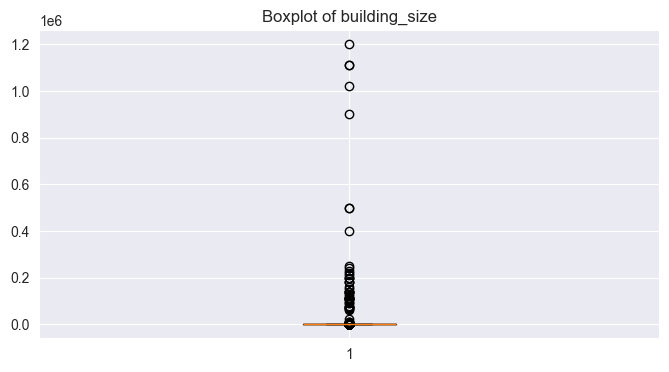

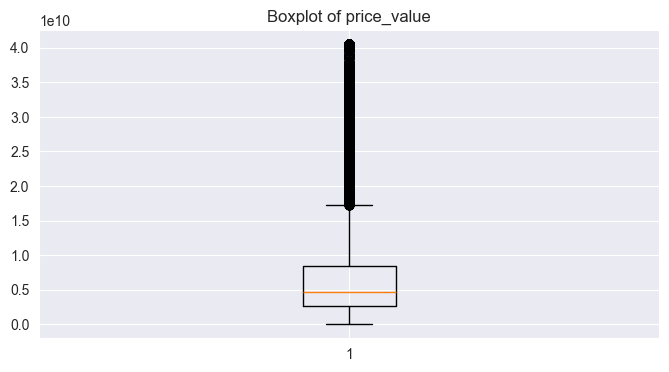

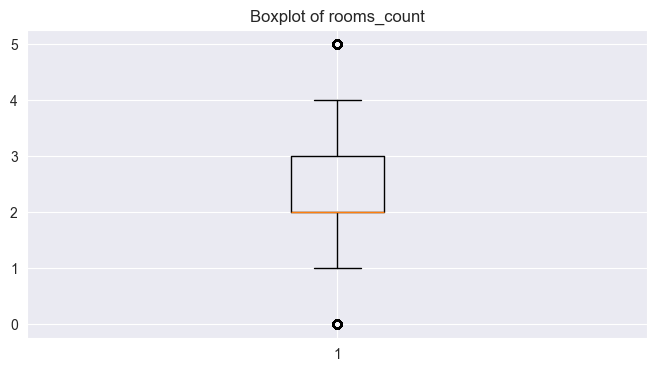

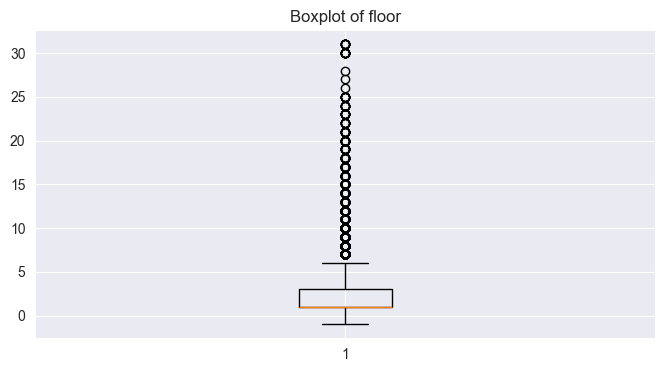

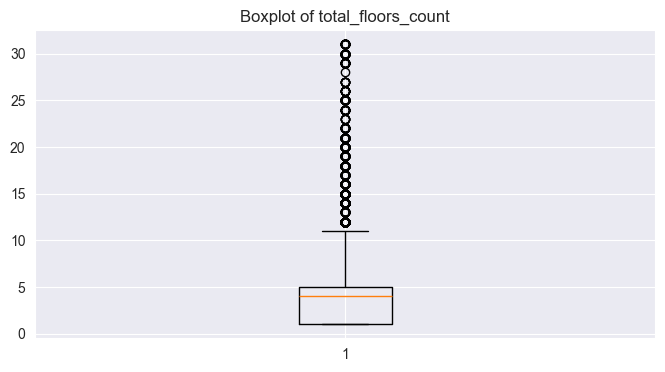

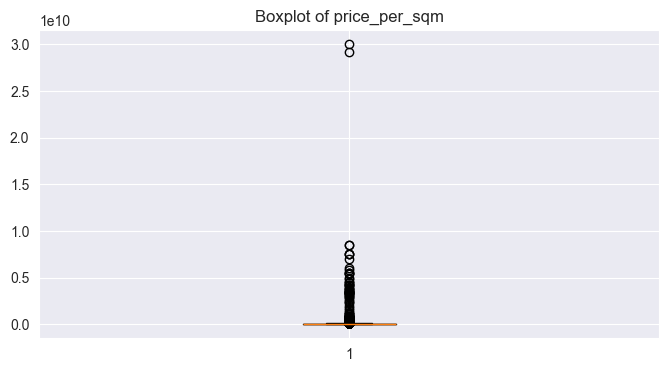

In [23]:

numeric_cols = ['building_size', 'price_value', 'rooms_count', 'floor', 'total_floors_count', 'price_per_sqm']

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    plt.boxplot(my_df_encoded[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.show()


In [24]:

numeric_cols = my_df_encoded.select_dtypes(include='number').columns.tolist()

one_hot_cols = [col for col in numeric_cols if set(my_df_encoded[col].unique()) <= {0,1}]
numeric_cols_to_check = [col for col in numeric_cols if col not in one_hot_cols and col not in ['location_latitude','location_longitude']]


def check_outliers(df, cols, method='iqr', capping=True, log_transform=False):
    outlier_info = {}
    df_clean = df.copy()

    for col in cols:
        series = df[col].dropna()

        if log_transform:
            series = np.log1p(series)  # log(1 + x)

        if method == 'iqr':
            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

        elif method == 'zscore':
            z_scores = np.abs(zscore(series))
            outliers = df[z_scores > 3][col]

        outlier_info[col] = {
            'num_outliers': len(outliers),
            'percent_outliers': len(outliers)/len(df) * 100,
            'lower_bound': lower_bound if method=='iqr' else None,
            'upper_bound': upper_bound if method=='iqr' else None
        }

        print(f"ستون {col} → تعداد پرت‌ها: {len(outliers)}, درصد: {len(outliers)/len(df)*100:.2f}%")

        if capping and method=='iqr':
            df_clean[col] = np.where(df_clean[col] < lower_bound, lower_bound, df_clean[col])
            df_clean[col] = np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col])

    return df_clean, outlier_info

my_df_clean, outlier_summary = check_outliers(my_df_encoded, numeric_cols_to_check, method='iqr', capping=True)


lat_lower, lat_upper = my_df_encoded['location_latitude'].quantile([0.01, 0.99])
lon_lower, lon_upper = my_df_encoded['location_longitude'].quantile([0.01, 0.99])

my_df_clean['location_latitude'] = np.clip(my_df_encoded['location_latitude'], lat_lower, lat_upper)
my_df_clean['location_longitude'] = np.clip(my_df_encoded['location_longitude'], lon_lower, lon_upper)

scaler = RobustScaler()
my_df_clean[['location_latitude', 'location_longitude']] = scaler.fit_transform(
    my_df_clean[['location_latitude', 'location_longitude']]
)


ستون age → تعداد پرت‌ها: 0, درصد: 0.00%
ستون building_size → تعداد پرت‌ها: 4515, درصد: 6.46%
ستون price_value → تعداد پرت‌ها: 6102, درصد: 8.73%
ستون rooms_count → تعداد پرت‌ها: 1983, درصد: 2.84%
ستون floor → تعداد پرت‌ها: 1464, درصد: 2.09%
ستون total_floors_count → تعداد پرت‌ها: 1426, درصد: 2.04%
ستون price_per_sqm → تعداد پرت‌ها: 3274, درصد: 4.68%


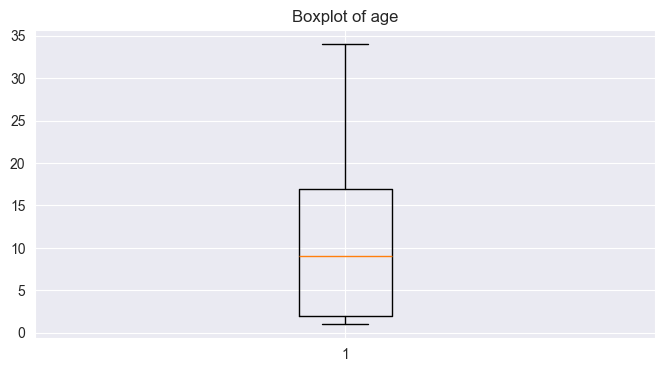

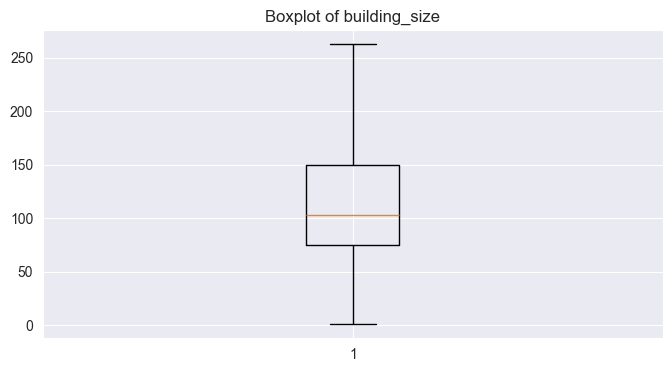

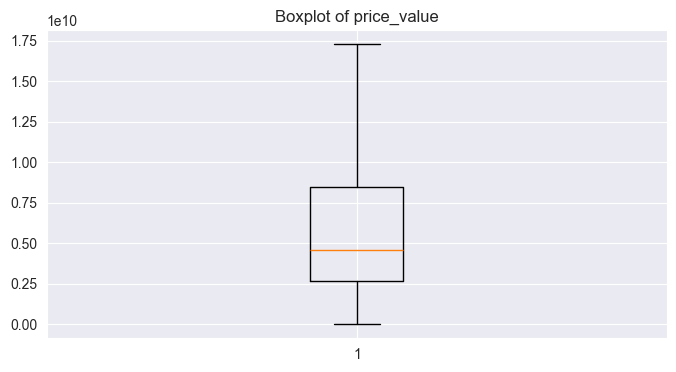

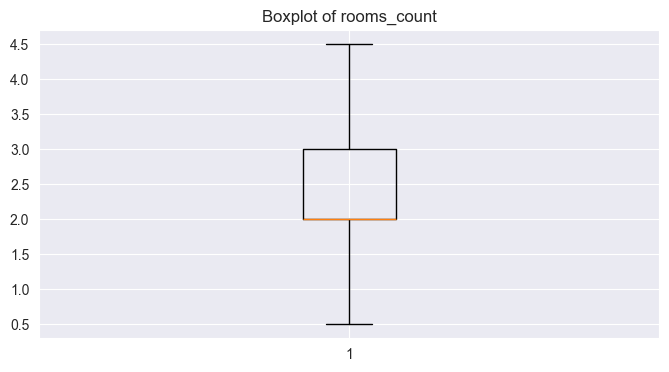

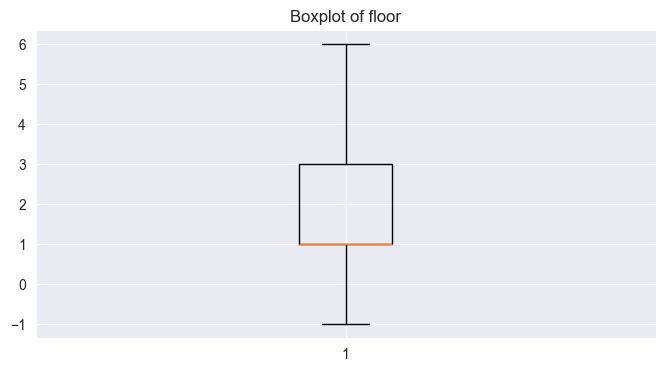

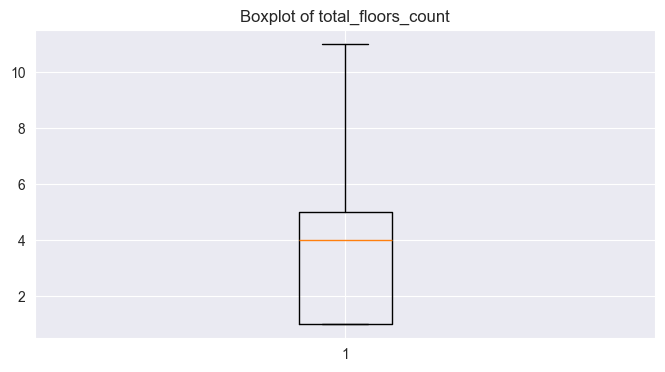

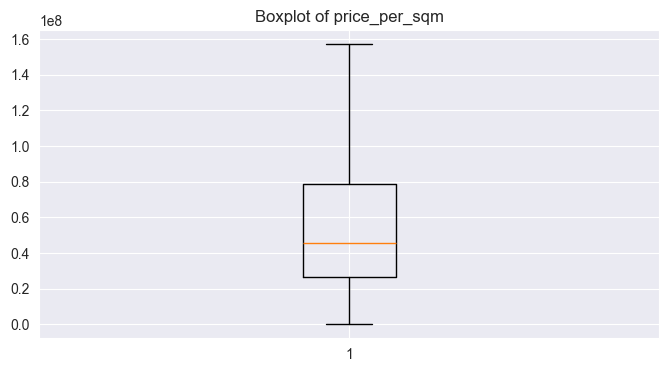

In [25]:

numeric_cols = ['age','building_size', 'price_value', 'rooms_count', 'floor', 'total_floors_count', 'price_per_sqm']

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    plt.boxplot(my_df_clean[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.show()


### Correlation and Variance of features
- removing highly correlated features
- removing features with low variance

In [26]:
# Correlation matrix
numeric_cols = my_df_clean.select_dtypes(include='number').columns

corr_matrix = my_df_clean[numeric_cols].corr()
print(corr_matrix)


                           age  building_size  price_value  rooms_count  \
age                   1.000000      -0.083476    -0.056050    -0.100523   
building_size        -0.083476       1.000000     0.462004     0.743845   
price_value          -0.056050       0.462004     1.000000     0.477569   
rooms_count          -0.100523       0.743845     0.477569     1.000000   
has_parking          -0.281854       0.284698     0.290963     0.308362   
has_balcony          -0.238208       0.126074     0.205823     0.190663   
has_elevator         -0.356917      -0.158185     0.324722     0.023045   
has_warehouse        -0.072052       0.107150     0.149259     0.125994   
location_latitude    -0.076473      -0.158802     0.032631    -0.107983   
location_longitude   -0.109667       0.055178    -0.051298     0.075712   
floor                -0.203992      -0.121286     0.229007     0.013613   
total_floors_count   -0.220755      -0.235153     0.260818    -0.051985   
warm_package         -0.4

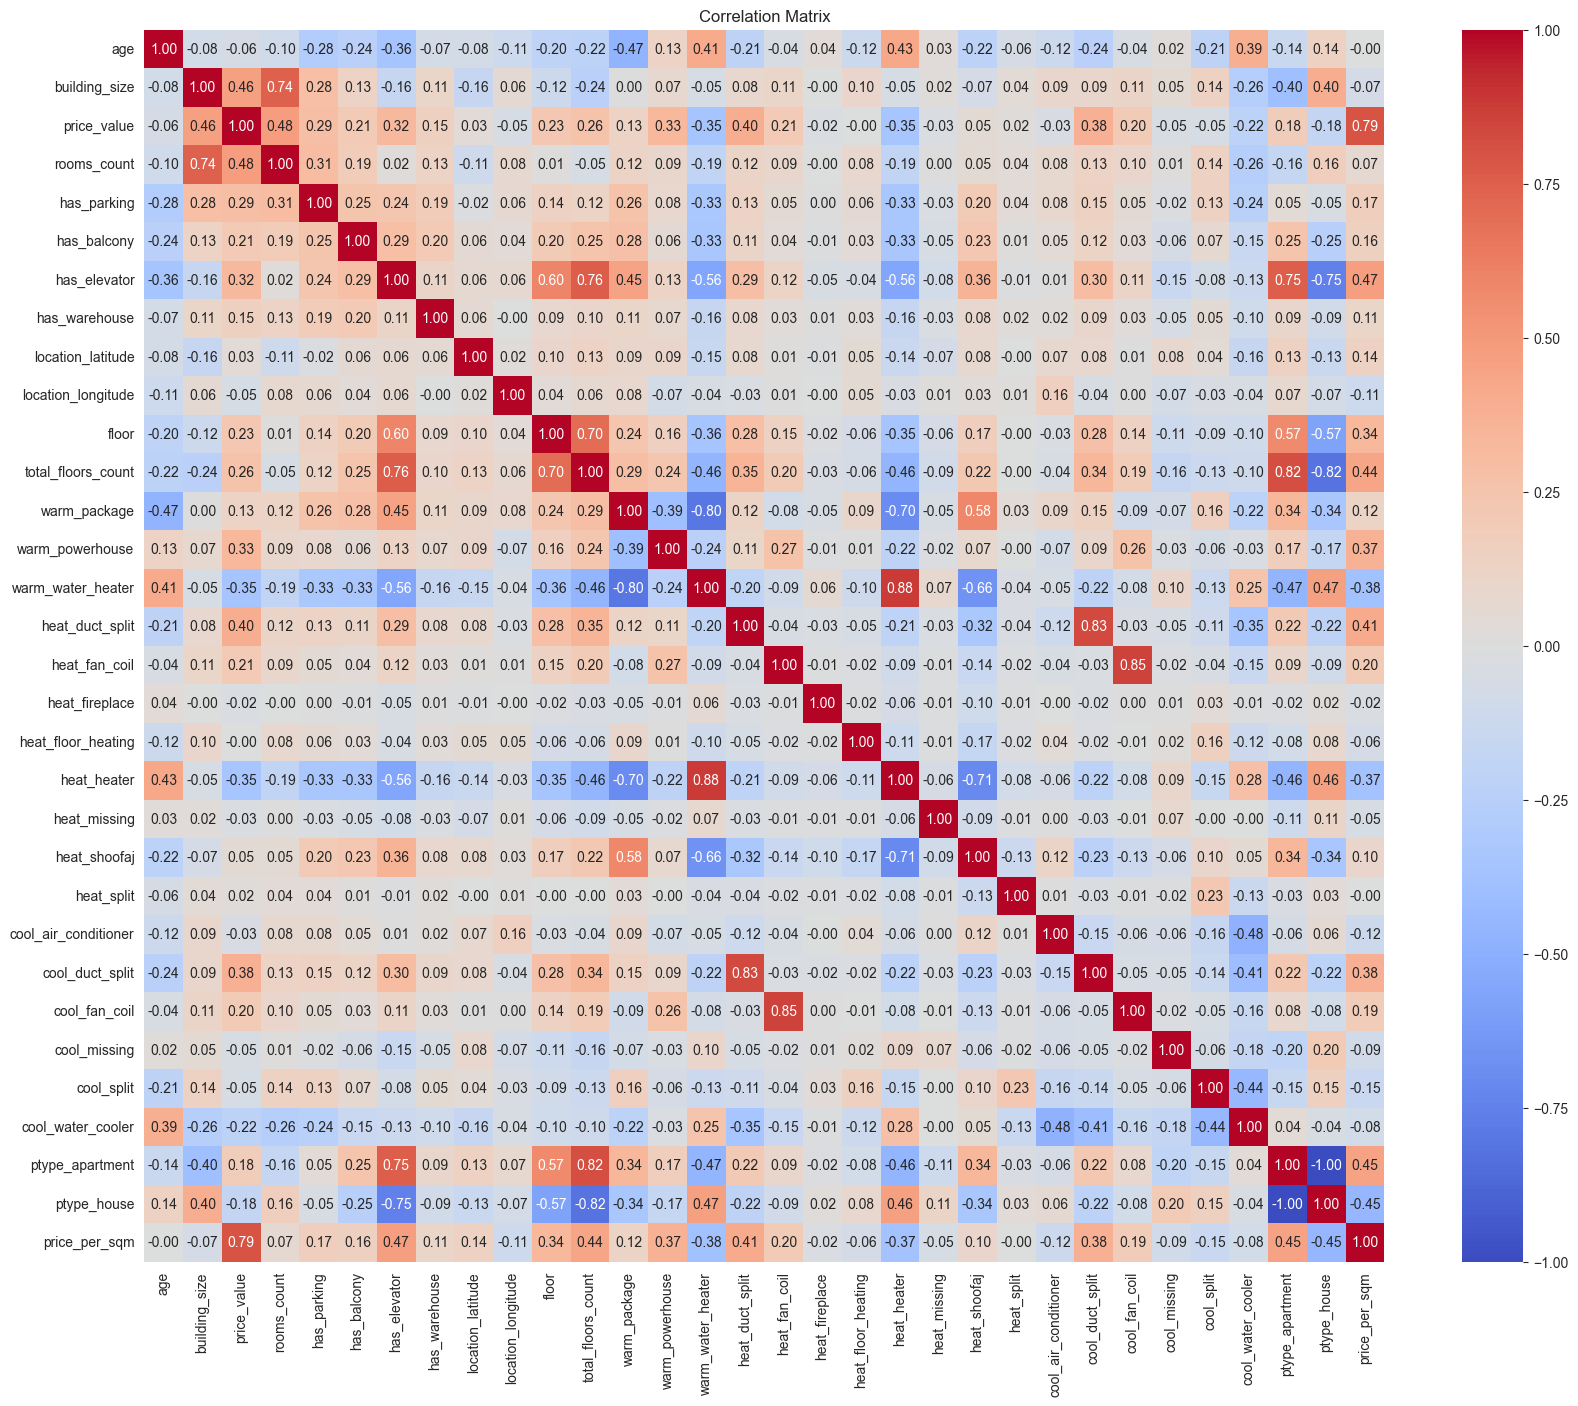

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


In [28]:
import numpy as np
threshold = 0.7

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column].abs() > threshold)]


print("ستون‌هایی که باید بررسی شوند و احتمال حذف دارند:", to_drop)


ستون‌هایی که باید بررسی شوند و احتمال حذف دارند: ['rooms_count', 'total_floors_count', 'warm_water_heater', 'heat_heater', 'heat_shoofaj', 'cool_duct_split', 'cool_fan_coil', 'ptype_apartment', 'ptype_house', 'price_per_sqm']


In [29]:
my_df_clean['amenities_score'] = 6 * my_df_clean['has_parking'] + 3 * my_df_clean['has_warehouse'] + my_df_clean['has_balcony']
to_drop = ['cool_fan_coil','cool_duct_split','ptype_house',"price_value","rooms_count","has_elevator",
"cool_split","heat_heater","warm_package","heat_shoofaj","has_parking","has_warehouse","has_balcony","ptype_apartment"]

my_df_clean = my_df_clean.drop(columns=to_drop)

In [31]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor



def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    
    vif_data["VIF"] = [variance_inflation_factor(df.values, i)
                       for i in range(len(df.columns))]
    return vif_data.sort_values(by="VIF", ascending=False)

vif_df = calculate_vif(my_df_clean)
print(vif_df)

                 feature        VIF
18       amenities_score  10.319609
5     total_floors_count   7.880183
1          building_size   5.928906
4                  floor   5.858723
17         price_per_sqm   5.120453
16     cool_water_cooler   4.918959
0                    age   3.669981
7      warm_water_heater   2.358601
8        heat_duct_split   2.038650
14  cool_air_conditioner   1.827572
6        warm_powerhouse   1.473473
9          heat_fan_coil   1.307003
2      location_latitude   1.205967
15          cool_missing   1.154498
3     location_longitude   1.133281
11    heat_floor_heating   1.079062
13            heat_split   1.063554
12          heat_missing   1.023703
10        heat_fireplace   1.016584


In [32]:
my_df_clean

,age,building_size,location_latitude,location_longitude,floor,total_floors_count,warm_powerhouse,warm_water_heater,heat_duct_split,heat_fan_coil,heat_fireplace,heat_floor_heating,heat_missing,heat_split,cool_air_conditioner,cool_missing,cool_water_cooler,price_per_sqm,amenities_score
0,1.0,170.0,3.274349,0.935277,1.0,1.0,0,0,0,0,0,0,0,0,1,0,0,9.411765e+05,10
1,24.0,65.0,0.416700,-0.600606,1.0,1.0,0,1,0,0,0,0,0,0,0,0,1,5.923077e+07,10
2,29.0,100.0,8.083200,-7.252111,1.0,1.0,0,1,0,0,0,0,0,0,1,0,0,5.200000e+07,4
3,17.0,160.0,2.308869,11.868660,1.0,1.0,0,1,0,0,0,0,0,0,0,0,1,1.875000e+07,10
4,24.0,120.0,8.022397,-3.546436,1.0,1.0,0,1,0,0,0,0,0,0,0,0,0,3.500000e+07,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69899,23.0,52.0,-0.375726,0.150070,3.0,4.0,0,1,0,0,0,0,0,0,0,0,1,3.846154e+07,4
69900,1.0,66.0,0.030066,0.136010,4.0,5.0,0,0,0,0,0,0,0,0,0,0,1,1.196970e+08,10
69901,12.0,61.0,-0.030735,-0.112207,3.0,5.0,0,0,0,0,0,0,0,0,0,0,1,9.754098e+07,10
69902,1.0,215.0,0.098609,-0.115227,2.0,5.0,0,0,1,0,0,0,0,0,0,0,0,1.302326e+08,10


In [33]:
numeric_cols = my_df_clean.select_dtypes(include='number').columns

variance = my_df_clean[numeric_cols].var()
print(variance)

age                     7.952360e+01
building_size           3.618098e+03
location_latitude       4.910683e+01
location_longitude      1.740162e+01
floor                   2.216668e+00
total_floors_count      5.240669e+00
warm_powerhouse         9.501524e-02
warm_water_heater       2.205543e-01
heat_duct_split         7.938903e-02
heat_fan_coil           1.752078e-02
heat_fireplace          8.776716e-03
heat_floor_heating      2.510049e-02
heat_missing            7.468092e-03
heat_split              1.534990e-02
cool_air_conditioner    1.249694e-01
cool_missing            2.221479e-02
cool_water_cooler       2.446703e-01
price_per_sqm           1.650806e+15
amenities_score         7.155856e+00
dtype: float64


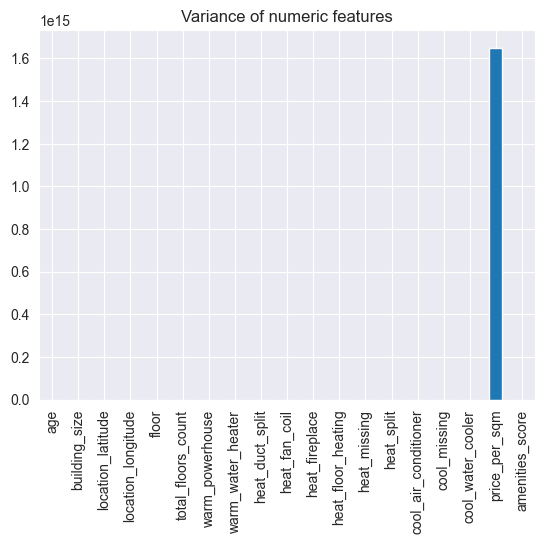

In [34]:
import matplotlib.pyplot as plt

variance.plot(kind='bar', title='Variance of numeric features')
plt.show()



## Standardizing data using fit method and transform


In [35]:
scaler = StandardScaler()

my_df_scaled_array = scaler.fit_transform(my_df_clean)

my_df_scaled = pd.DataFrame(my_df_scaled_array, columns=my_df_clean.columns)

print("واریانس داده‌های اسکیل شده:")
print(my_df_scaled.var())

واریانس داده‌های اسکیل شده:
age                     1.000014
building_size           1.000014
location_latitude       1.000014
location_longitude      1.000014
floor                   1.000014
total_floors_count      1.000014
warm_powerhouse         1.000014
warm_water_heater       1.000014
heat_duct_split         1.000014
heat_fan_coil           1.000014
heat_fireplace          1.000014
heat_floor_heating      1.000014
heat_missing            1.000014
heat_split              1.000014
cool_air_conditioner    1.000014
cool_missing            1.000014
cool_water_cooler       1.000014
price_per_sqm           1.000014
amenities_score         1.000014
dtype: float64


In [36]:
my_df_scaled.shape

(69904, 19)

In [37]:
my_df_scaled

,age,building_size,location_latitude,location_longitude,floor,total_floors_count,warm_powerhouse,warm_water_heater,heat_duct_split,heat_fan_coil,heat_fireplace,heat_floor_heating,heat_missing,heat_split,cool_air_conditioner,cool_missing,cool_water_cooler,price_per_sqm,amenities_score
0,-1.080142,0.836233,0.754284,-0.005188,-0.736993,-1.050025,-0.344913,-0.699261,-0.308590,-0.134769,-0.09452,-0.16262,-0.087073,-0.125856,2.414656,-0.152512,-1.158481,-1.390917,0.536908
1,1.499045,-0.909397,0.346490,-0.373373,-0.736993,-1.050025,-0.344913,1.430080,-0.308590,-0.134769,-0.09452,-0.16262,-0.087073,-0.125856,-0.414138,-0.152512,0.863199,0.043733,0.536908
2,2.059738,-0.327521,1.440520,-1.967887,-0.736993,-1.050025,-0.344913,1.430080,-0.308590,-0.134769,-0.09452,-0.16262,-0.087073,-0.125856,2.414656,-0.152512,-1.158481,-0.134234,-1.706063
3,0.714075,0.669982,0.616508,2.615787,-0.736993,-1.050025,-0.344913,1.430080,-0.308590,-0.134769,-0.09452,-0.16262,-0.087073,-0.125856,-0.414138,-0.152512,0.863199,-0.952598,0.536908
4,1.499045,0.004980,1.431844,-1.079554,-0.736993,-1.050025,-0.344913,1.430080,-0.308590,-0.134769,-0.09452,-0.16262,-0.087073,-0.125856,-0.414138,-0.152512,-1.158481,-0.552646,0.536908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69899,1.386907,-1.125523,0.233409,-0.193420,0.606338,0.260457,-0.344913,1.430080,-0.308590,-0.134769,-0.09452,-0.16262,-0.087073,-0.125856,-0.414138,-0.152512,0.863199,-0.467449,-1.706063
69900,-1.080142,-0.892772,0.291317,-0.196790,1.278003,0.697284,-0.344913,-0.699261,-0.308590,-0.134769,-0.09452,-0.16262,-0.087073,-0.125856,-0.414138,-0.152512,0.863199,1.531956,0.536908
69901,0.153382,-0.975897,0.282640,-0.256293,0.606338,0.697284,-0.344913,-0.699261,-0.308590,-0.134769,-0.09452,-0.16262,-0.087073,-0.125856,-0.414138,-0.152512,0.863199,0.986642,0.536908
69902,-1.080142,1.584360,0.301098,-0.257017,-0.065327,0.697284,-0.344913,-0.699261,3.240548,-0.134769,-0.09452,-0.16262,-0.087073,-0.125856,-0.414138,-0.152512,-1.158481,1.791262,0.536908


# Kmeans clustering

In [38]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist


## Finding the Optimal Number of Clusters Using WCSS ##

In [39]:
def find_optimal_clusters(X_scaled, max_k=15):
    distortions = []
    inertias = []
    K = range(2, max_k)

    for k in K:
        kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeanModel.fit(X_scaled)

        distortions.append(
            sum(np.min(cdist(X_scaled, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X_scaled.shape[0]
        )
        inertias.append(kmeanModel.inertia_)

    return distortions, inertias, K

distortions, inertias, K = find_optimal_clusters(my_df_scaled)

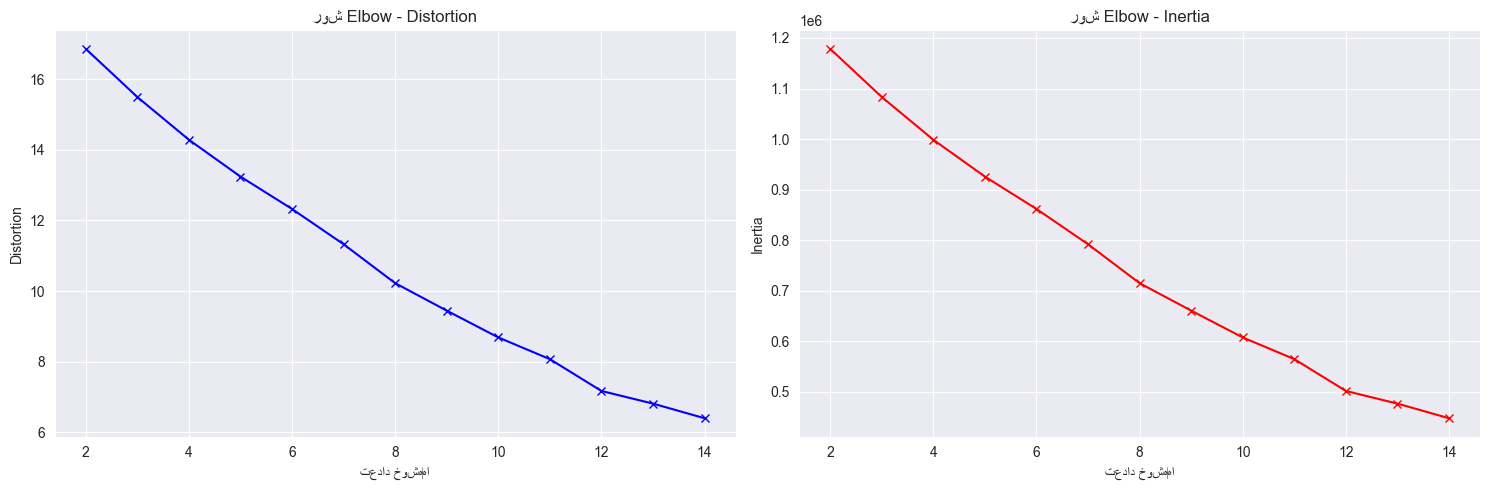

In [40]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(K, distortions, 'bx-')
plt.xlabel('تعداد خوشه‌ها')
plt.ylabel('Distortion')
plt.title('روش Elbow - Distortion')

plt.subplot(1, 2, 2)
plt.plot(K, inertias, 'rx-')
plt.xlabel('تعداد خوشه‌ها')
plt.ylabel('Inertia')
plt.title('روش Elbow - Inertia')

plt.tight_layout()
plt.show()

##### Silhouette score

In [ ]:
ss = []

for i in range(2,15):
    km = KMeans(n_clusters = i)
    km.fit(my_df_scaled)
    ss.append(silhouette_score(my_df_scaled, km.labels_, metric='euclidean'))

Text(0, 0.5, 'Silhouette Score')

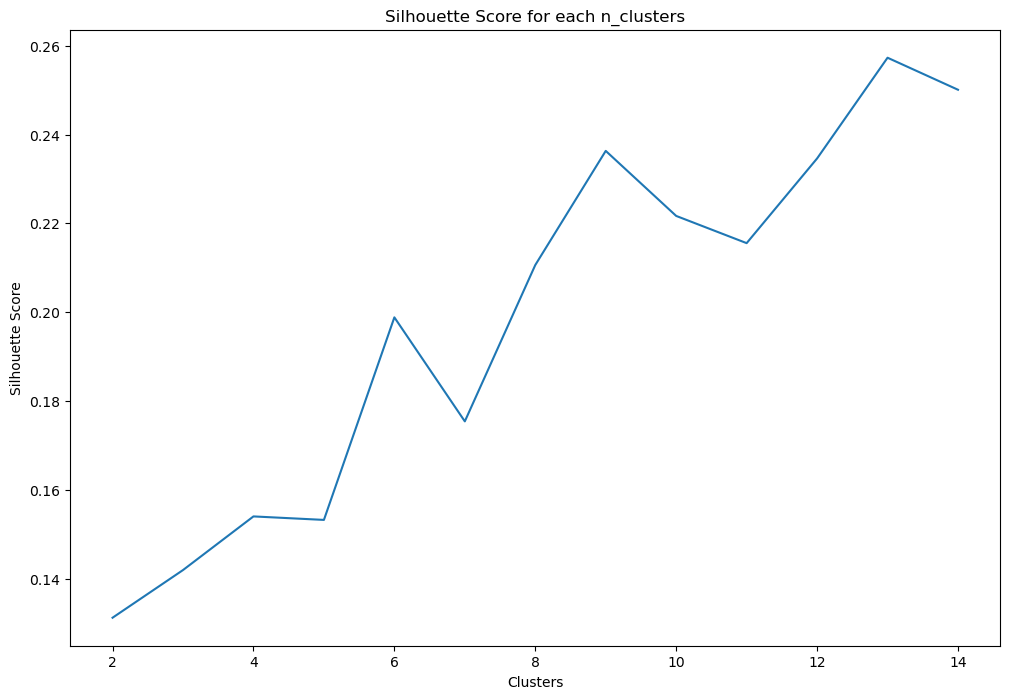

In [38]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.lineplot(x=list(range(2, 15)), y=ss, ax=ax)
ax.set_title('Silhouette Score for each n_clusters')
ax.set_xlabel('Clusters')
ax.set_ylabel('Silhouette Score')

In [60]:
optimal_k = 9

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(my_df_scaled)

my_df['kmeans_cluster'] = kmeans.labels_

In [ ]:
from sklearn.metrics import silhouette_score

# Silhouette score can be expensive on large datasets, so a sample is used for portfolio reproducibility.
score = silhouette_score(my_df_scaled, kmeans.labels_, sample_size=min(10000, len(my_df_scaled)), random_state=42)
print("Silhouette Score:", score)


In [ ]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=my_df_scaled.columns)
centers


In [ ]:
print("\nتحلیل خوشه‌ها:")
clustered_df = my_df_scaled.copy()
clustered_df["kmeans_cluster"] = kmeans.labels_
cluster_analysis = clustered_df.groupby("kmeans_cluster").mean()
cluster_analysis


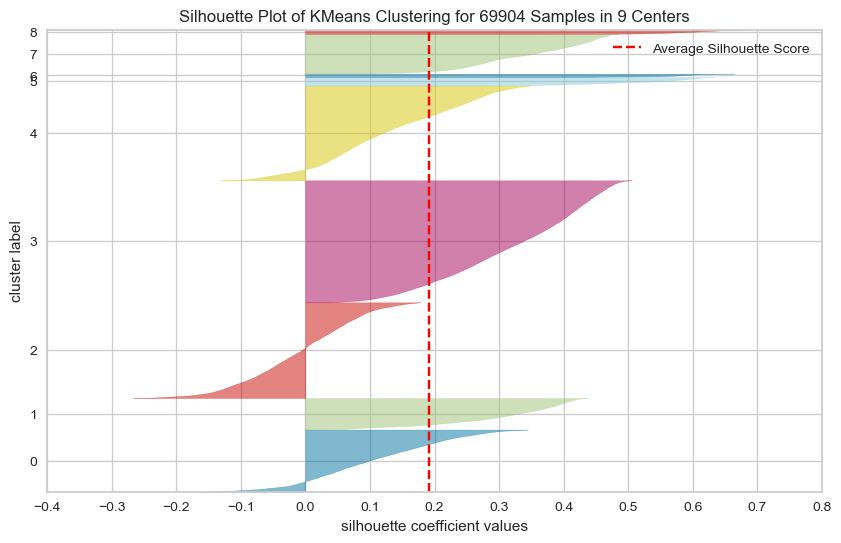

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 69904 Samples in 9 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [44]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer
import pandas as pd


fig, ax = plt.subplots(1, 1, figsize=(10, 6))

k_value = 9

km = KMeans(n_clusters=k_value, random_state=42, n_init='auto')

visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax)


visualizer.fit(my_df_scaled)

visualizer.show()

#### DBSCAN clustering

In [45]:
from sklearn.cluster import DBSCAN

### Selecting Epsilon (eps) using the k-Distance Graph

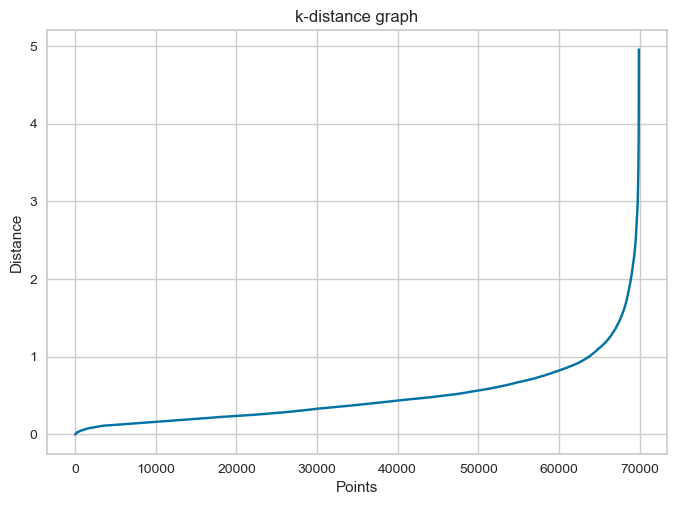

In [46]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 4  # مقدار پیشنهادی اولیه
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(my_df_scaled)
distances, indices = neighbors_fit.kneighbors(my_df_scaled)

distances = np.sort(distances[:, -1])
plt.plot(distances)
plt.title("k-distance graph")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()


In [47]:
dbscan = DBSCAN(eps = 0.4, min_samples =16)
dbscan_clusters = dbscan.fit_predict(my_df_scaled)
length = len(np.unique(clusters))


In [48]:
my_df['dbscan_cluster'] = dbscan.labels_
print("DBSCAN clusters assigned.")
print(f"Number of DBSCAN clusters (excluding noise): {len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0)}")
print(f"Number of noise points: {(dbscan_clusters == -1).sum()}")


DBSCAN clusters assigned.
Number of DBSCAN clusters (excluding noise): 188
Number of noise points: 46459


In [49]:

labels = dbscan.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Clusters:", n_clusters)
print("Noise points:", n_noise)

Clusters: 188
Noise points: 46459


In [50]:
from sklearn.metrics import silhouette_score

if n_clusters > 1:
    print(silhouette_score(my_df_scaled, labels))
else:
    print("Only 1 cluster → Silhouette not applicable")


-0.38047671618877293


In [51]:
cluster_means = pd.DataFrame(columns=my_df_scaled.columns)

for c in set(labels):
    if c != -1:
        cluster_means.loc[c] = my_df_scaled[labels == c].mean()

cluster_means


,age,building_size,location_latitude,location_longitude,floor,total_floors_count,warm_powerhouse,warm_water_heater,heat_duct_split,heat_fan_coil,heat_fireplace,heat_floor_heating,heat_missing,heat_split,cool_air_conditioner,cool_missing,cool_water_cooler,price_per_sqm,amenities_score
0,0.458790,-0.887482,0.217253,-0.294825,-0.736993,-1.050025,-0.344913,1.430080,-0.308590,-0.134769,-0.09452,-0.162620,-0.087073,-0.125856,-0.414138,-0.152512,0.863199,-0.827196,-1.912801
1,-0.611199,2.350300,0.299511,-0.364662,-0.736993,-1.050025,-0.344913,1.430080,-0.308590,-0.134769,-0.09452,-0.162620,-0.087073,-0.125856,-0.414138,-0.152512,0.863199,-1.145303,0.507778
2,-0.994692,0.725203,0.741048,-0.016723,-0.736993,-1.050025,-0.344913,-0.699261,-0.308590,-0.134769,-0.09452,6.149308,-0.087073,-0.125856,-0.414138,-0.152512,-1.158481,-1.070971,0.497106
3,-0.250509,-0.484978,0.274495,-0.356456,-0.736993,-1.050025,-0.344913,1.430080,-0.308590,-0.134769,-0.09452,-0.162620,-0.087073,-0.125856,-0.414138,-0.152512,0.863199,-0.644222,0.470467
4,-0.977335,0.611079,0.797301,-0.124693,-0.736993,-1.050025,-0.344913,-0.699261,-0.308590,-0.134769,-0.09452,-0.162620,-0.087073,-0.125856,-0.414138,-0.152512,-1.158481,-0.886000,0.508930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,-0.968004,-0.103082,-1.396214,-0.123819,1.278003,0.697284,-0.344913,-0.699261,-0.308590,-0.134769,-0.09452,-0.162620,-0.087073,-0.125856,-0.414138,-0.152512,0.863199,-0.281163,0.536908
184,-0.985710,-0.005520,0.299733,-0.221775,1.278003,1.134111,-0.344913,-0.699261,3.240548,-0.134769,-0.09452,-0.162620,-0.087073,-0.125856,-0.414138,-0.152512,-1.158481,2.380534,0.536908
185,-0.239103,-0.884460,0.290825,-0.254279,-0.065327,0.697284,2.899278,-0.699261,-0.308590,-0.134769,-0.09452,-0.162620,-0.087073,-0.125856,-0.414138,-0.152512,0.863199,1.186219,0.536908
186,-0.162008,-1.012265,0.262419,-0.219005,-0.065327,0.260457,-0.344913,-0.699261,-0.308590,-0.134769,-0.09452,-0.162620,-0.087073,-0.125856,-0.414138,-0.152512,0.863199,0.323997,-0.584577


In [52]:
def report_metrics(X, labels, name):
    """گزارش معیارهای عددی کیفیت خوشه بندی."""
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters < 2:
        print(f"--- {name} Metrics ---")
        print("کمتر از دو خوشه شناسایی شد. معیارهای داخلی محاسبه نشد.")
        return

    # فیلتر کردن نویز DBSCAN برای محاسبه دقیق‌تر
    X_filtered = X[labels != -1] if -1 in labels else X
    labels_filtered = labels[labels != -1] if -1 in labels else labels

    print(f"\n--- {name} Metrics ---")
    print(f"تعداد خوشه‌های معنادار: {n_clusters}")
    print(f"امتیاز سیلوئت (Silhouette): {silhouette_score(X_filtered, labels_filtered):.4f}")


report_metrics(my_df_scaled, kmeans.labels_, "K-Means")
report_metrics(my_df_scaled, dbscan.labels_, "DBSCAN")


--- K-Means Metrics ---
تعداد خوشه‌های معنادار: 9
امتیاز سیلوئت (Silhouette): 0.2131

--- DBSCAN Metrics ---
تعداد خوشه‌های معنادار: 188
امتیاز سیلوئت (Silhouette): 0.1602


تجزیه مؤلفه‌های اصلی (PCA) در حال انجام...


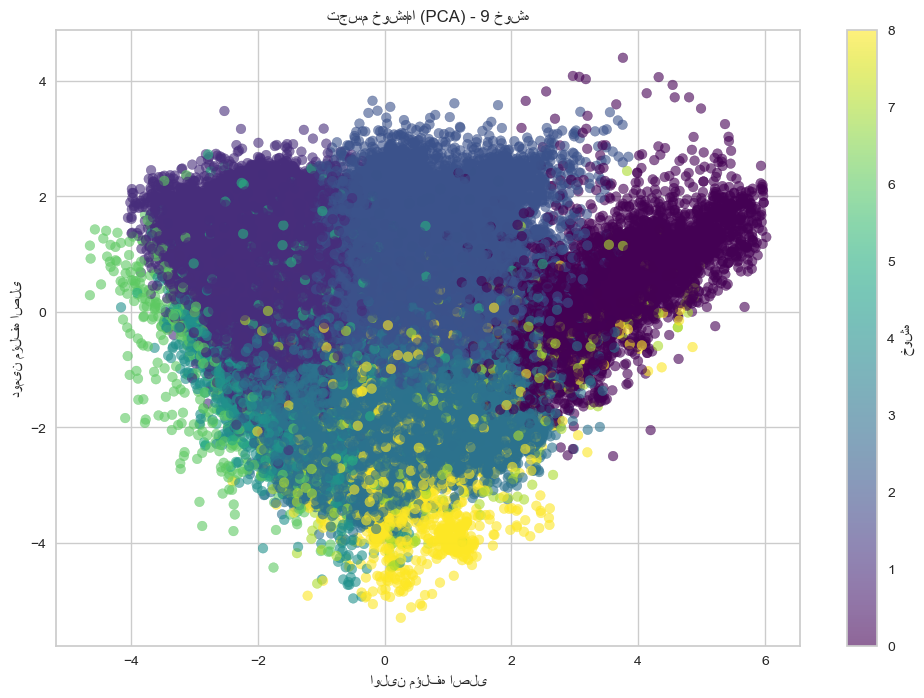

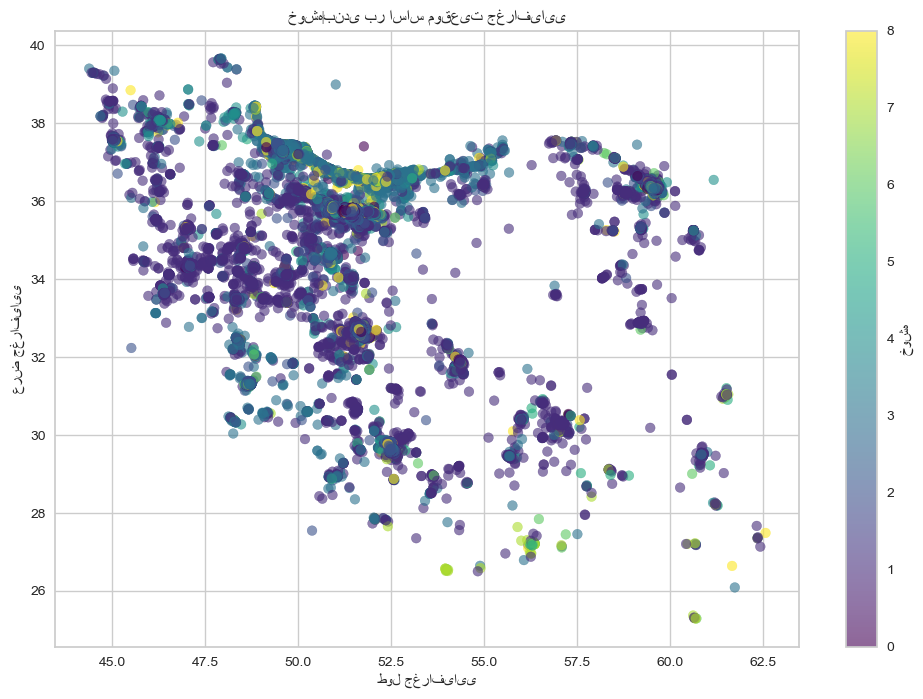


--- مراکز خوشه‌ها (مقادیر واقعی) ---
         age  building_size  location_latitude  location_longitude     floor  \
0   4.926206     140.898172          -0.424547            0.617733  3.567129   
1  16.716454     118.215738          -4.595365            1.023563  1.257793   
2  10.251603      97.387170          -1.943077            0.335129  2.658949   
3   6.321092     141.241721           0.256331            2.142511  1.780468   
4  11.917956     139.190316           2.105633           -1.082124  1.000000   
5  14.190630     118.529079          -2.777245            0.942771  1.741519   
6  13.482890     133.910646          -7.244814            1.475107  1.000000   
7   6.718349     138.390826          -2.124726            1.221924  2.065138   
8   4.184074     155.374495           0.179790            2.379463  1.527409   

   total_floors_count  warm_powerhouse  warm_water_heater  heat_duct_split  \
0            6.258348         0.311117           0.011955     8.238285e-01   
1    

In [61]:
from sklearn.decomposition import PCA

print("تجزیه مؤلفه‌های اصلی (PCA) در حال انجام...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(my_df_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6) 
plt.colorbar(scatter, label='خوشه')
plt.xlabel('اولین مؤلفه اصلی')
plt.ylabel('دومین مؤلفه اصلی')
plt.title(f'تجسم خوشه‌ها (PCA) - {optimal_k} خوشه')
plt.show()

plt.figure(figsize=(12, 8))
scatter = plt.scatter(my_df['location_longitude'],
                      my_df['location_latitude'],
                      c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='خوشه')
plt.xlabel('طول جغرافیایی')
plt.ylabel('عرض جغرافیایی')
plt.title('خوشه‌بندی بر اساس موقعیت جغرافیایی')
plt.show()

centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

centers_df = pd.DataFrame(centers_original, columns=features)
centers_df['kmeans_cluster'] = range(optimal_k)

print("\n--- مراکز خوشه‌ها (مقادیر واقعی) ---")
print(centers_df)

print(f"\n--- نتایج نهایی ---")
print(f"تعداد خوشه‌ها: {optimal_k}")
print(f"تعداد داده‌های خوشه‌بندی شده: {len(my_df_scaled)}")

## Dimension reduction
Using PCA in preprocessing

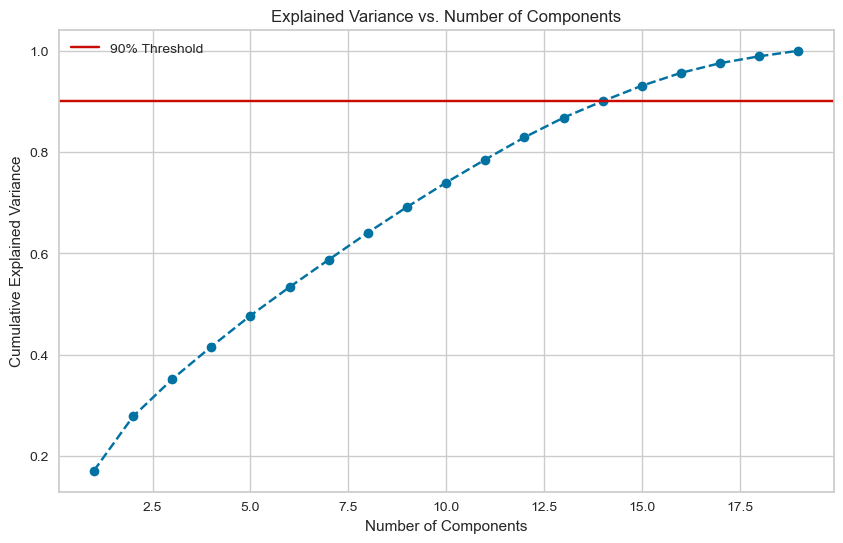

In [62]:
pca = PCA()
pca.fit(my_df_scaled)

explained_variance_ratio = pca.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Explained Variance vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Threshold')
plt.legend()
plt.show()

In [63]:
n_components = 5

pca_final = PCA(n_components=n_components)
X_pca = pca_final.fit_transform(my_df_scaled)

print(f"ابعاد داده‌های اصلی: {my_df_scaled.shape}")
print(f"ابعاد داده‌های کاهش یافته (PCA): {X_pca.shape}")

ابعاد داده‌های اصلی: (69904, 19)
ابعاد داده‌های کاهش یافته (PCA): (69904, 5)
